# Resarch workflow

0. Research hypotheses
-------------

1. Loading data
2. Initial EDA
3. Preprocesing
4. Deep EDA
5. Assumption checking
6. Statistical testing
7. Effect sizes
-------------
8. Reporting / writeup

# 0. Research hypotheses

1. QUESTION: How much time on average Finnish households spend daily on each activity?

APPROACH:

2. With respect to which activities do living environments or days of week differ in Finland?

APPROACH:


3. Which activities are associated with each other in Finnish population?

APPROACH:

In [ ]:
import pandas as pd
import numpy as np
from scipy import stats
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Loading the data

In [ ]:
df = pd.read_csv("habits.data", sep=";")

# 2. Initial EDA

Overview:
- head()
- Renaming columns
- shape
- dtypes
- isna().sum()
- duplicated().sum()
- nunique()

In [ ]:
df.head(10)

# OBSERVATION: Upon inital running of df.head(10), the data was loaded as 1 column,
# and all values were separated by ;.
# I returned to read_csv and added sep=";"

,kohde,jasen,pvknro,sp,ASALUE,IKAL1,A1,A2,A3,A4,A5
0,50002,1,2,1,1.0,6,190,450,13,2.0,1.0
1,50002,2,2,2,1.0,6,235,480,52,1.0,1.0
2,50009,1,2,2,1.0,7,175,460,104,1.0,1.0
3,50011,1,2,2,3.0,4,180,460,0,1.0,1.0
4,50012,1,1,2,1.0,8,0,600,10,2.0,2.0
5,50015,1,1,1,3.0,8,0,480,310,2.0,1.0
6,50015,2,1,2,3.0,8,0,520,40,2.0,1.0
7,50022,1,1,2,1.0,6,480,570,0,2.0,1.0
8,50024,1,2,1,1.0,4,340,490,0,2.0,1.0
9,50030,1,2,1,2.0,6,0,570,91,1.0,1.0


In [ ]:
# Additonaly, the choice was made to reload the data and rename most of the columns to a more recognizable word format
# Instead of using a list for new column names, a dictionary was used,
# to remove the requirement of the same indexing as the orignal column

col_names = {"kohde": "household_ID", "jasen": "member_ID", "pvknro": "day_of_week", "sp": "sex", "IKAL1": "age_group", "ASALUE": "living_env", "A1": "working", "A2": "sleeping", "A3": "reading", "A4": "restaurant_dining", "A5": "visiting_lib"}
df = df.rename(columns=col_names)

# df.rename was used, since it was discovered taht re-running pd.read_csv with paramter names=,
# only accepts a list, and not a dictionary

In [ ]:
df.head(3)

,household_ID,member_ID,day_of_week,sex,living_env,age_group,working,sleeping,reading,restaurant_dining,visiting_lib
0,50002,1,2,1,1.0,6,190,450,13,2.0,1.0
1,50002,2,2,2,1.0,6,235,480,52,1.0,1.0
2,50009,1,2,2,1.0,7,175,460,104,1.0,1.0


In [ ]:
df.shape
# 780 rows, and 11 columns present in the data

(780, 11)

In [ ]:
df.dtypes

,0
household_ID,int64
member_ID,int64
day_of_week,int64
sex,int64
living_env,float64
age_group,int64
working,object
sleeping,object
reading,object
restaurant_dining,object


In [ ]:
# OBSERVATION: All columns that are "object" type likely contain strings,
# and are marked for more rigorous analysis

In [ ]:
df.isna().sum()

,0
household_ID,0
member_ID,0
day_of_week,0
sex,0
living_env,0
age_group,0
working,0
sleeping,0
reading,0
restaurant_dining,0


In [ ]:
# OBSERVATION: isna().sum() is not detecting any missing values in the dataset,
# however, it only scans for values marked as NaN, and ignores strings, zeros, and other possible invalid characthers.
# A more rigorous inspection for missing values and placeholders will be carried out in preprocessing

In [ ]:
df.duplicated().sum()

np.int64(0)

In [ ]:
# OBSERVATION: Checking if every single value in a row matches every single value in another.
# No matches were found

In [ ]:
df.nunique()

,0
household_ID,494
member_ID,2
day_of_week,2
sex,2
living_env,3
age_group,7
working,95
sleeping,99
reading,82
restaurant_dining,8


In [ ]:
# Nunique() was used to see if the project documentation in habits.txt matches our data,
# and for more insight into the data structure

# OBSERVATION:
# 1 household_ID - There are 494 unique households in the dataset
# 2 member_ID - matches description (1-2 members per household)
# 3 day_of_week - matches description (1 working day, 2 weekend)
# 4 sex - matches description (binary)
# 5 age_group - age group has 7, however the project documentation divided into 9.
# This means that participants from at least 2 age ranges were absent in the data

# 6 living_env - matches description (1 city, 2 municipality, 3 rural)
# 7 working - 95 unique instances
# 8 sleeping - 99 unique instances
# 9 reading - 82
# 10 restaurant_dining - 8
# 11 visiting_lib - 6

# 3. Preprocessing

Overview:
- 1 Imputing
- - 1.1 Inspecting for missing / placeholder values
- - 1.2 Converting activity column values
- - 1.3 Handling missing values
- - 1.4 Filling data (Imputation / dropping rows)
- - 1.5 Cleaning last 2 columns

- 2 Encoding
- - Variable classification

- 3 Outlier handling

1.1 Inspecting for missing / placeholder values

In [ ]:
# A custom loop was created for looking at 10 unique instances across all columns to spot placeholders.
res1 = {}
for x in df:
  res1[x] = df[x].unique()[:10]
res1

# res[x] on the left, to create a key inisde a dictionary,
# and assign to it x column from the dataframe (df[x])

# I paid special attention to the value 0,
# which sometimes iteslf is used to encode for missing value (e.g 0 blood pressure)

{'household_ID': array([50002, 50009, 50011, 50012, 50015, 50022, 50024, 50030, 50035,
        50051]),
 'member_ID': array([1, 2]),
 'day_of_week': array([2, 1]),
 'sex': array([1, 2]),
 'living_env': array([1., 3., 2.]),
 'age_group': array([6, 7, 4, 8, 3, 9, 5]),
 'working': array(['190', '235', '175', '180', '0', '480', '340', '00:00', '370',
        '205'], dtype=object),
 'sleeping': array(['450', '480', '460', '600', '520', '570', '490', '680', '09:20',
        '09:30'], dtype=object),
 'reading': array(['13', '52', '104', '0', '10', '310', '40', '91', '00:00', '140'],
       dtype=object),
 'restaurant_dining': array(['2.0', '1.0', '?', '0.0', '60.0', '180.0', '120.0', '240.0'],
       dtype=object),
 'visiting_lib': array(['1.0', '2.0', '?', '180.0', '0.0', '120.0'], dtype=object)}

In [ ]:
# OBSERVATION:
# 1 household_ID - N/A
# 2 member_ID - no placeholders
# 3 day_of_week - no placeholders
# 4 sex - no placeholders
# 5 age_group - no placeholders
# 6 living_env - no placeholders

# 7 working - N/A
# 8 sleeping - N/A
# 9 reading - N/A
# Working, sleeping, and reading had over 80 unique values each,
# therefore they cannot be reliably inspected visually for placeholders as the other columns

# 10 restaurant_dining - placeholder: ?
# 11 visiting_lib - placeholder: ?
# As there are only 6-8 unique values for those columns (nunique),
# meaning they are able to be fully inspected.

1.2 Converting activity column values:

In [ ]:
# Aside from placeholders, I noticed that the format between the activities is very messy:
# e.g 'sleeping': array(['450', '480', '460', '600', '00:00', '570', '490', '680', '09:20', '09:30']),

# Working, sleeping, and reading all appear to primarily be in minutes,
# with some values logged in as hours.

# 00:00 format would have to be converted to plain 0,
# and values like 9:20 hours translated to minutes.

# The columns of restaurant_dining and visiting_lib,
# appear to not have any format in hours that would warrant conversion (already in minutes)

In [ ]:
df[["working", "sleeping", "reading", "restaurant_dining", "visiting_lib"]].head(20)

,working,sleeping,reading,restaurant_dining,visiting_lib
0,190,450,13,2.0,1.0
1,235,480,52,1.0,1.0
2,175,460,104,1.0,1.0
3,180,460,0,1.0,1.0
4,0,600,10,2.0,2.0
5,0,480,310,2.0,1.0
6,0,520,40,2.0,1.0
7,480,570,0,2.0,1.0
8,340,490,0,2.0,1.0
9,0,570,91,1.0,1.0


In [ ]:
# Initial reasoning was to use .replace() for reassigning 00:00 to 0, however that approach would only work for 0 values,
# and would fail completely for any other amount of time,
# as all other amounts are unique instances and require recalculation instead of .replace().

# Therefore a custom function was built to convert all individual instances to strings,
# check for : in each string instance, if yes then split into 2 parts, then do conversion math. Otherwise skip if no :

In [ ]:
def converter(actions):
  actions = str(actions) # read all instances across all action columns as strings
  if ":" in actions: # if current specific instance contains :, which is limited to only the instances that are in hours
    hours, minutes = actions.split(":") # create hours and minutes by splitting actions by :
    total = (int(hours) * 60) + int(minutes) # since hours and minutes are still strings by this point, converting them back to working format with int
    return total
  else:
    try:
      return int(float(actions))
    except:
      return actions


# Reasoning logic on 0: (hours)0 * 60 + (minutes)0 = 0, so this function also converts zeros sucessfully


# NOTE: I encountered errors trying to return just float(actions) without the try / except condition,
# as items like "?" were unable to be converted to float, since missing vals were not dealt with up to this point,
# therefore a try/except condition was set up:
# if the time is already in minutes,
# try converting it back from string to integer,
# otherwise if it doesnt work, return the value as a string, like "?", or "nan"


# Trying just float(actions), all valid values had .0 at the end,
# this was solved by adding int, meaning first convert string actions to float, then int

In [ ]:
a_cols = df[["working", "sleeping", "reading", "restaurant_dining", "visiting_lib"]]
res2 = {}
for x in a_cols:
  res2[x] = a_cols[x].unique()[:10]
res2

{'working': array(['190', '235', '175', '180', '0', '480', '340', '00:00', '370',
        '205'], dtype=object),
 'sleeping': array(['450', '480', '460', '600', '520', '570', '490', '680', '09:20',
        '09:30'], dtype=object),
 'reading': array(['13', '52', '104', '0', '10', '310', '40', '91', '00:00', '140'],
       dtype=object),
 'restaurant_dining': array(['2.0', '1.0', '?', '0.0', '60.0', '180.0', '120.0', '240.0'],
       dtype=object),
 'visiting_lib': array(['1.0', '2.0', '?', '180.0', '0.0', '120.0'], dtype=object)}

In [ ]:
# Applying the function to all actions columns.
# Given each value in those columns, transform each using the function created above, and overwrite the same columns with the results
df[["working", "sleeping", "reading", "restaurant_dining", "visiting_lib"]] = df[["working", "sleeping", "reading", "restaurant_dining", "visiting_lib"]].map(converter)

In [ ]:
res3 = {}
for x in a_cols:
  res3[x] = df[x].unique()[:10]
res3

# a_cols's 5 names are a subset of df's columns, so looping over a_cols succeeds,
# and gives us only the version of selected columns

{'working': array([190, 235, 175, 180, 0, 480, 340, 370, 205, 420], dtype=object),
 'sleeping': array([450, 480, 460, 600, 520, 570, 490, 680, 560, 540], dtype=object),
 'reading': array([13, 52, 104, 0, 10, 310, 40, 91, 140, 30], dtype=object),
 'restaurant_dining': array([2, 1, '?', 0, 60, 180, 120, 240], dtype=object),
 'visiting_lib': array([1, 2, '?', 180, 0, 120], dtype=object)}

In [ ]:
# OBSERVATION:
# All instances of hours appear to have been resolved and successsfully converted to minutes

# Additionally, only the values unable to be converted to floats were left as strings,
# visible in the case of question marks.

1.3 Handling missing values

In [ ]:
# Inspecting the data for instances of placeholders, focusing on the ?,
# and including additional placeholders that may be present
placeholders = ["?", "", " ", "NA", "N/A", "-", "--"]
print((df.isin(placeholders)).sum())

household_ID          0
member_ID             0
day_of_week           0
sex                   0
living_env            0
age_group             0
working               7
sleeping             10
reading               4
restaurant_dining    40
visiting_lib         38
dtype: int64


In [ ]:
# OBSERVATION: Placeholders were found in all activity columns,
# and will be adressed in the following step, with .apply(pd.to_numeric)

In [ ]:
# Inspection of values on household_ID column was done before deciding to run df.apply,
# as otherwise it would strip the formatting of any values with 0 padding (e.g 05020 would become something like 5020)

print(f"range:",df["household_ID"].min(),"-", df["household_ID"].max())

range: 50002 - 51982


In [ ]:
df = df.apply(pd.to_numeric, errors="coerce")

# The approach of df.apply was chosen over something like .replace(placeholders, np.nan),
# as it additionaly catches any instances of numbers encoded as strings if there are any, e.g "6" to 6,
# and was chosen for blanket placeholder conversion, ones not included in the "placeholders list"

In [ ]:
# Checking if conversion was successful:
print((df.isin(placeholders)).sum())

print((df.isna().sum()))

household_ID         0
member_ID            0
day_of_week          0
sex                  0
living_env           0
age_group            0
working              0
sleeping             0
reading              0
restaurant_dining    0
visiting_lib         0
dtype: int64
household_ID          0
member_ID             0
day_of_week           0
sex                   0
living_env            0
age_group             0
working               7
sleeping             10
reading               4
restaurant_dining    40
visiting_lib         38
dtype: int64


In [ ]:
# OBSERVATION: Everything that was not able to be converted to either an integer or float,
# like all "?" and other placeholders were successfully converted to NaN

In [ ]:
df.dtypes

,0
household_ID,int64
member_ID,int64
day_of_week,int64
sex,int64
living_env,float64
age_group,int64
working,float64
sleeping,float64
reading,float64
restaurant_dining,float64


In [ ]:
# OBSERVATION: All columns are now fully encoded as either integers or float,
# making them suitable for further preprocessing and analysis

1.4 Filling data (Imputation / dropping rows)

In [ ]:
# Imputing the mode was chosen for the columns restaurant_dining and visiting_lib
# compared to dropping the rows, since if the rows do not overlap,
# we would lose about 10% of our data.

# Therefore imputation with the most common value was chosen for those columns:
restaurant_dining_mode = df["restaurant_dining"].mode()[0]
visiting_lib_mode = df["visiting_lib"].mode()[0]
# No missing values were filled in the 1st attempt when [0] was not inlcuded at the end,
# and the output was a series instead of a single number.
# [0] was added at the end was to extract the first element, which solved mode imputation

df["restaurant_dining"] = df["restaurant_dining"].fillna(restaurant_dining_mode)
df["visiting_lib"] = df["visiting_lib"].fillna(visiting_lib_mode)

# Median imputation was chosen for the 3 numeric activity columns,
# as it is more robust to outliers compared to the mean:
working_median = df["working"].median()
sleeping_median = df["sleeping"].median()
reading_median = df["reading"].median()

df["working"] = df["working"].fillna(working_median)
df["sleeping"] = df["sleeping"].fillna(sleeping_median)
df["reading"] = df["reading"].fillna(reading_median)

In [ ]:
df.isna().sum()

,0
household_ID,0
member_ID,0
day_of_week,0
sex,0
living_env,0
age_group,0
working,0
sleeping,0
reading,0
restaurant_dining,0


1.5 Cleaning last 2 columns:

In [ ]:
# For activity columns, it was also noted in the documentation that values 1 = yes, and 2 = no.
# Inspecting all activity columns for such instances, or if they are present in the other 3 columns also:
df[["working", "sleeping", "reading", "restaurant_dining", "visiting_lib"]].isin([1, 2]).sum()

,0
working,0
sleeping,0
reading,0
restaurant_dining,762
visiting_lib,762


In [ ]:
df.shape

(780, 11)

In [ ]:
# OBSERVATION:
# From the activites, only the columns of restaurant_dining, and visiting_lib have the values 1 = yes, and 2 = no.

In [ ]:
# Since only about 55 out of 725 columns are logged as minutes,
# it was decided to convert all instances of minutes into an implicit yes,
# as those participants are non-representative of the sample.

# It was reasoned it would make more sense to have everyone in those 2 columns binarized,
# rather than separating the sub-population with time as a separate column

# APPROACH:
# From the dataset description:
# 1 = yes
# 2 = no

# For all instances of 0, replacing them as 2 (no):
df[["restaurant_dining", "visiting_lib"]] = df[["restaurant_dining", "visiting_lib"]].replace(0, 2)

In [ ]:
# All other minute instances (any value other than 0), if > 2, then have it as = 1 (yes), otherwise skip

for x in df["restaurant_dining"]:
  if x > 2: # if any x instance in those 2 columns is greater than 2,
    df["restaurant_dining"] = df["restaurant_dining"].replace(x, 1) # rewrite the original column and replace it with 1 (meaning yes)
  else:
    continue # otherwise, skip

for x in df["visiting_lib"]:
  if x > 2:
    df["visiting_lib"] = df["visiting_lib"].replace(x, 1)
  else:
    continue

In [ ]:
# Inspecting if 1 and 2 are the only instances in those 2 columns:
print(df["restaurant_dining"].unique())
print(df["visiting_lib"].unique())

print(df["restaurant_dining"].shape)
print(df["visiting_lib"].shape)

# OBSERVATION: both columns now strictly contain values 1 and 2, with no other vals.

[2. 1.]
[1. 2.]
(780,)
(780,)


2. Encoding

In [ ]:
res4 = {}
for x in df:
  res4[x] = df[x].unique()[:10]

In [ ]:
# VARIABLE CLASSIFICATION & APPROACH:
# 1 household_ID - continuous numeric variable, N/A (encoding only applies to categorical, not numerical variables)
# 2 member_ID - binary, no encoding needed
# 3 day_of_week - binary, no encoding needed
# 4 sex - binary, no encoding needed
# 5 age_group - ordinal, already encoded

# 6 living_env - nominal by nature, however currently as ordinal,
# since e.g living in a city is not inherently better than rural.
# Choice to not change the current formatting was made,
# since based on the hypothesses, no regression model will need be used on living_env.

# 7 working - continuous numeric variable, N/A
# 8 sleeping - continuous numeric variable, N/A
# 9 reading - continuous numeric variable, N/A
# 10 restaurant_dining - binary, no encoding needed
# 11 visiting_lib - binary, no encoding needed

3. Outlier handling

array([[<Axes: title={'center': 'household_ID'}>,
        <Axes: title={'center': 'member_ID'}>,
        <Axes: title={'center': 'day_of_week'}>],
       [<Axes: title={'center': 'sex'}>,
        <Axes: title={'center': 'living_env'}>,
        <Axes: title={'center': 'age_group'}>],
       [<Axes: title={'center': 'working'}>,
        <Axes: title={'center': 'sleeping'}>,
        <Axes: title={'center': 'reading'}>],
       [<Axes: title={'center': 'restaurant_dining'}>,
        <Axes: title={'center': 'visiting_lib'}>, <Axes: >]], dtype=object)

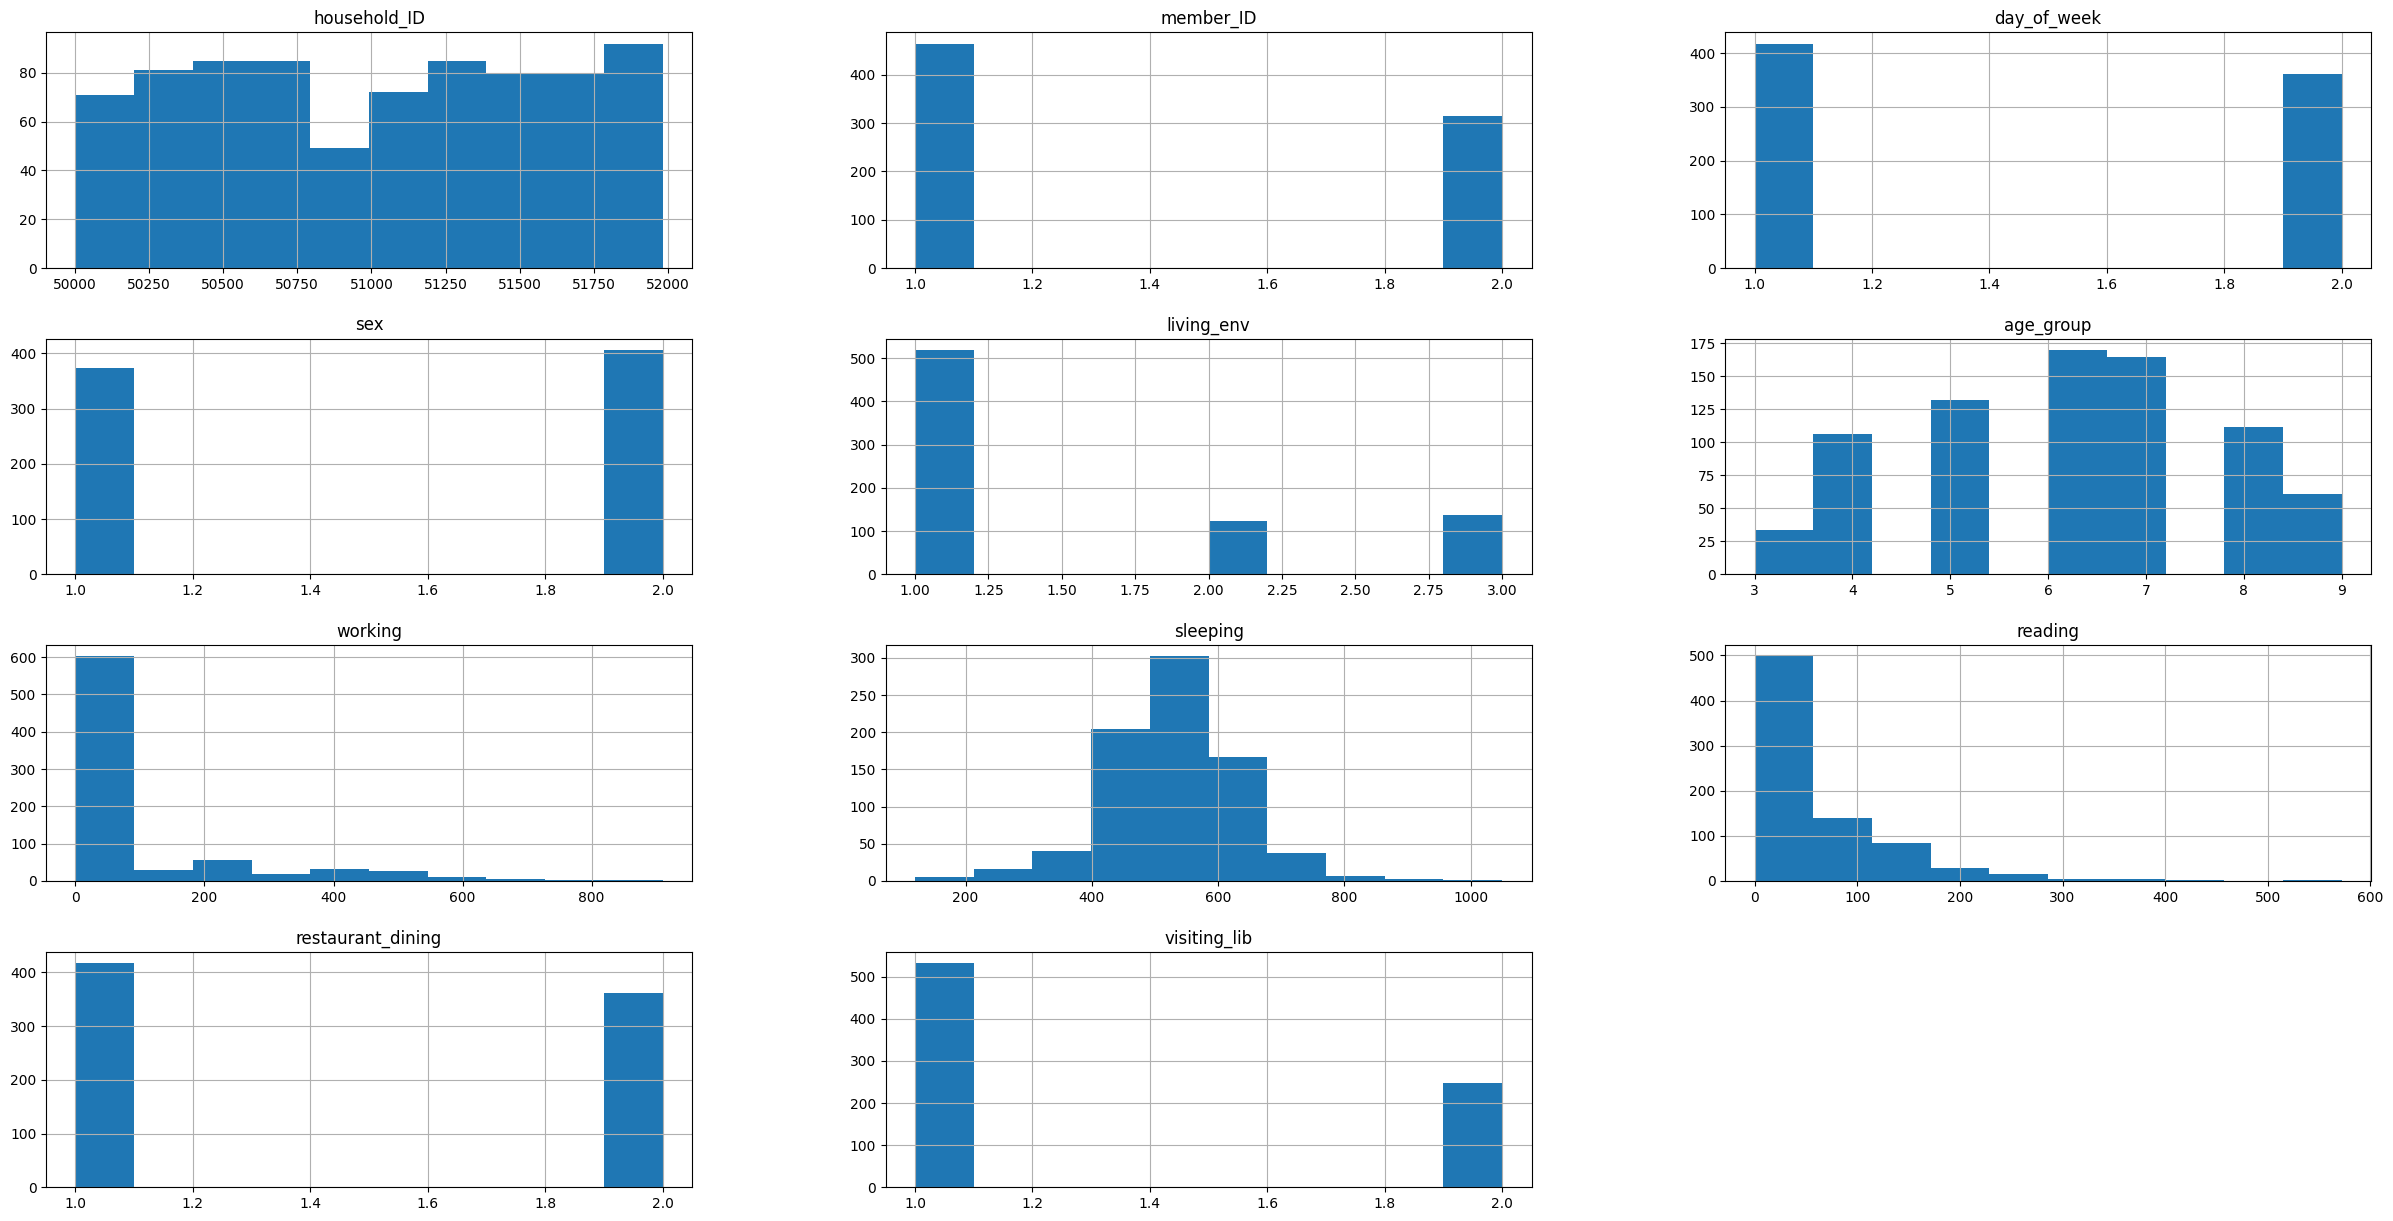

In [ ]:
# Plotting histograms for every column at once:
df.hist(figsize=(30, 15))

In [ ]:
# OBSERVATION:
# 1 household_ID - N/A (identification codes, household_ID is an identifier, not a measured quantity),
# and outlier detection does not apply to categorical / identifier variables

# 2 member_ID - N/A, binary
# 3 day_of_week - N/A, binary
# 4 sex - N/A, binary
# 5 living_env - N/A, nominal
# 6 age_group - for the age group, it is suposed to be 9 columns, and 2 missing since .nunique() it showed 7,
# but on the plot it is showing 3 gaps, likely because of the bin number
# Otherwise roughly normally distributed

# 7 working - extreme positive skew, will be inspected closely
# 8 sleeping - roughly normally distributed
# 9 reading - very strong positive skew, will be inspected closely
# 10 restaurant_dining - N/A, binary
# 11 visiting_lib - N/A, binary

# N/A for binary columns since we cannot have any outliers simply because it is either/or category

,0
household_ID,"Axes(0.125,0.11;0.0596154x0.77)"
member_ID,"Axes(0.196538,0.11;0.0596154x0.77)"
day_of_week,"Axes(0.268077,0.11;0.0596154x0.77)"
sex,"Axes(0.339615,0.11;0.0596154x0.77)"
living_env,"Axes(0.411154,0.11;0.0596154x0.77)"
age_group,"Axes(0.482692,0.11;0.0596154x0.77)"
working,"Axes(0.554231,0.11;0.0596154x0.77)"
sleeping,"Axes(0.625769,0.11;0.0596154x0.77)"
reading,"Axes(0.697308,0.11;0.0596154x0.77)"
restaurant_dining,"Axes(0.768846,0.11;0.0596154x0.77)"


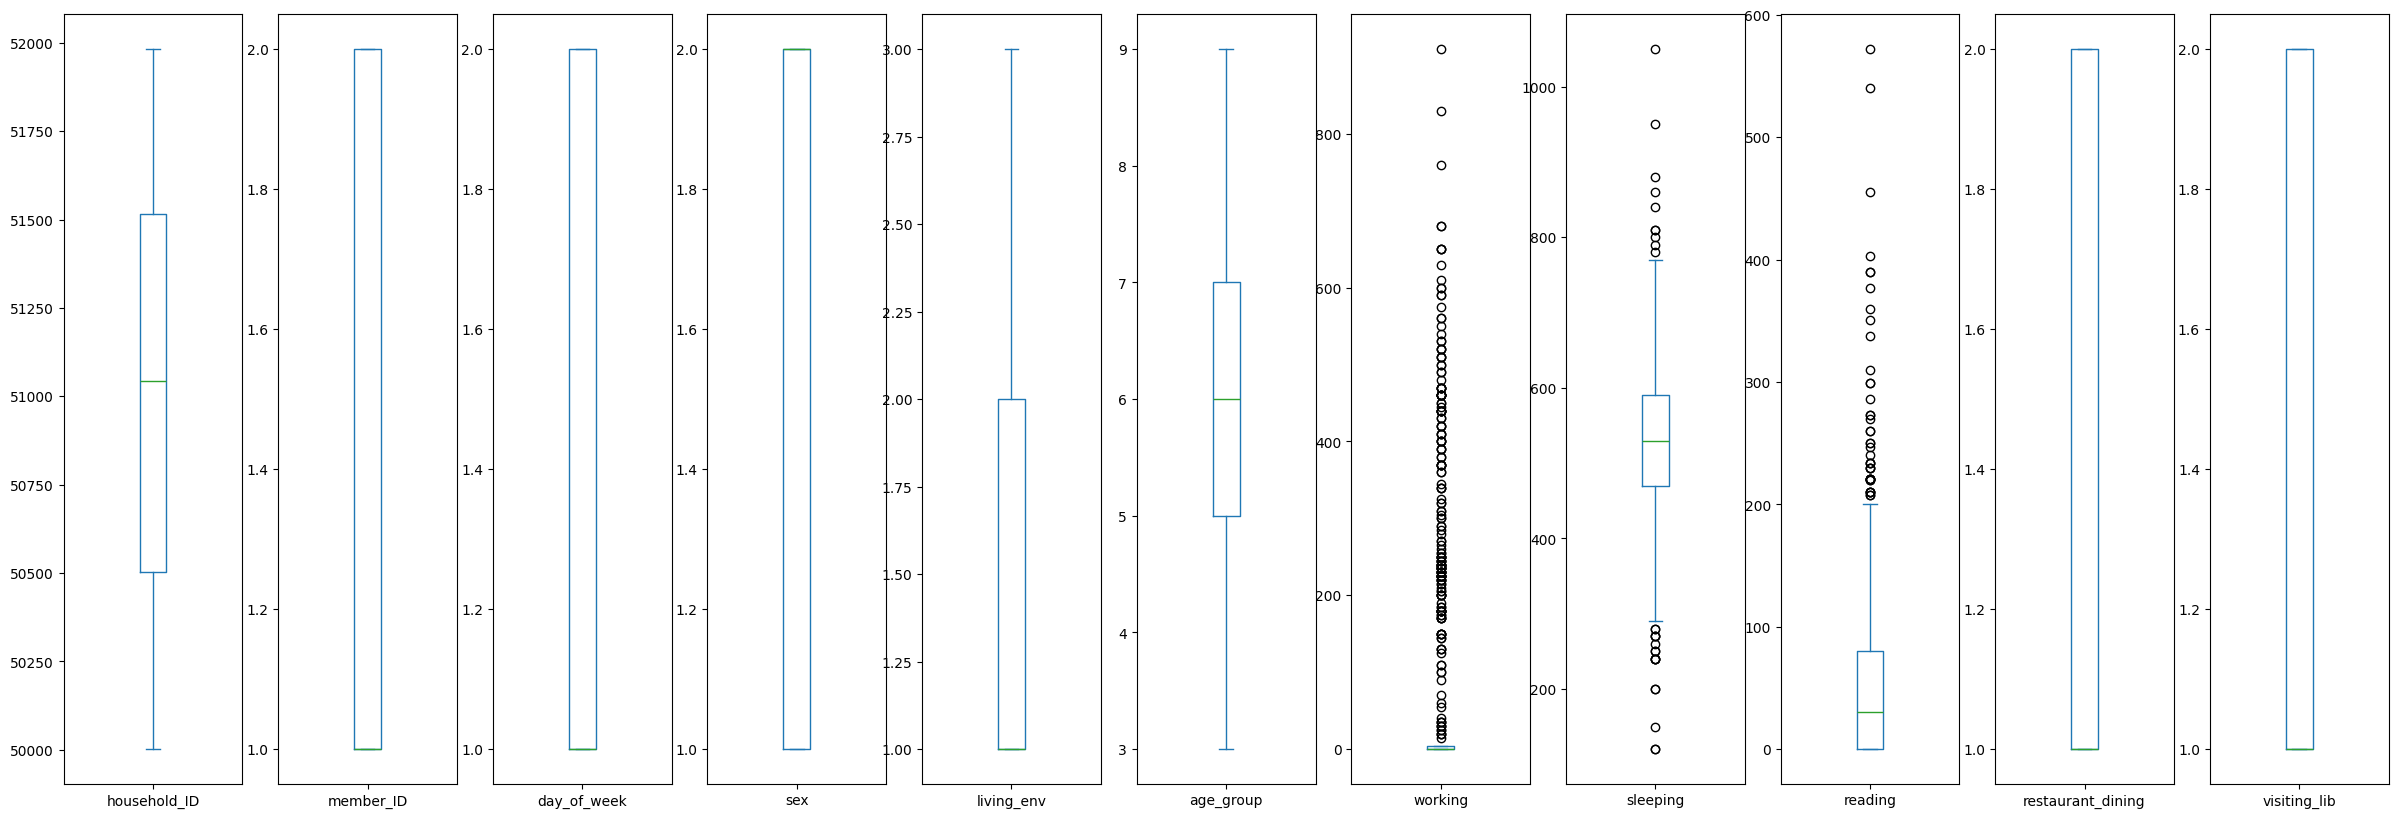

In [ ]:
# Boxplots:
df.plot(kind="box", subplots=True, figsize=(30, 10))

In [ ]:
# OBSERVATION:
# Working, sleeping, and reading flagged as having outliers (especially working and reading as identified above).
# All three will be inspected more closely by looking at min and max values for each column respectively:

In [ ]:
max15_working = df["working"].sort_values(ascending=False).head(15)
min15_working = df["working"].sort_values().head(15)
print(max15_working)
print(min15_working)

541    910.0
233    830.0
234    760.0
59     680.0
464    680.0
197    650.0
550    650.0
200    650.0
272    630.0
342    610.0
155    600.0
507    600.0
524    590.0
420    590.0
513    575.0
Name: working, dtype: float64
397    0.0
407    0.0
406    0.0
405    0.0
403    0.0
402    0.0
401    0.0
400    0.0
399    0.0
398    0.0
408    0.0
396    0.0
395    0.0
394    0.0
433    0.0
Name: working, dtype: float64


In [ ]:
# OBSERVATION:
# All values appear plausible given the context of the column.
# Maximum working value of 910 minutes translates to 15.2 hours, which is still plausible
910/60
# On the min end there are no negative values.

15.166666666666666

In [ ]:
max15_sleeping = df["sleeping"].sort_values(ascending=False).head(15)
min15_sleeping = df["sleeping"].sort_values().head(15)
print(max15_sleeping)
print(min15_sleeping)

758    1050.0
227     950.0
647     880.0
559     860.0
280     840.0
662     810.0
592     810.0
512     800.0
776     790.0
679     780.0
372     770.0
628     770.0
362     760.0
157     760.0
532     760.0
Name: sleeping, dtype: float64
483    120.0
482    120.0
744    150.0
382    200.0
659    200.0
106    240.0
68     240.0
502    240.0
761    240.0
456    250.0
197    250.0
180    260.0
570    270.0
762    270.0
65     270.0
Name: sleeping, dtype: float64


In [ ]:
# OBSERVATION:
# Maximum sleeping value was 17.5 hours, not impossible
# Minimum sleeping value was 4.5, also passes
print(1050/60)
print(270/60)

17.5
4.5


In [ ]:
max15_reading = df["reading"].sort_values(ascending=False).head(15)
min15_reading = df["reading"].sort_values().head(15)
print(max15_reading)
print(min15_reading)

208    572.0
93     540.0
603    455.0
388    403.0
151    390.0
380    390.0
97     377.0
766    360.0
723    351.0
675    338.0
5      310.0
381    299.0
616    299.0
131    286.0
418    273.0
Name: reading, dtype: float64
506    0.0
235    0.0
236    0.0
238    0.0
239    0.0
240    0.0
241    0.0
242    0.0
213    0.0
503    0.0
231    0.0
508    0.0
509    0.0
511    0.0
512    0.0
Name: reading, dtype: float64


In [ ]:
# OBSERVATION:
# Maximum reading time was under 6 hours, and on the minimum end, no negative values

In [ ]:
# DECISION:
# Based on the 3 columns, no impossible values were found,
# and the decision was made to retain all as-is since there are no data-entry errors, and no rows were dropped.

# 4. Deep EDA

Overview:
- ...
- ...

In [ ]:
df.describe()

NameError: name 'df' is not defined